# Práctica 3 PVC
### Natalia Martínez García y Lucía Vega Navarrete - Grupo 1.1

### COSAS QUE HACER: 
### Ver si ajustamos los píxeles en undersampling (esto es sevcundario, podemos dejarlo como está)

In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
from skimage import io
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
from skimage.morphology import binary_opening, binary_closing, disk, remove_small_objects, remove_small_holes
from scipy.ndimage import maximum_filter, minimum_filter, uniform_filter, sobel
from skimage.filters import frangi

In [2]:
# Fijamos la semilla para poder reproducir los resultados
import random
seed = 123
np.random.seed(seed)
random.seed(seed)

## Ejercicio 1 -  Segmentación de carreteras en imagen aérea de alta resolución

### Carga del dataset

Primero cargamos todas las imágenes de satélite y sus máscaras correspondientes desde las carpetas del dataset. Para garantizar que cada imagen está emparejada con su máscara correcta, primero se listan y ordenan los archivos. Después, las imágenes se leen tal cual y las máscaras se binarizan para obtener valores 0/1. Luego, todo se convierte en arrays NumPy para poder procesarlo de forma eficiente en los siguientes pasos de la práctica. Por último, imprimimos las dimensiones de las imágenes para comprobar que todo se ha cargado correctamente. 

In [3]:
# Ruta al dataset
# Lo tenemos en la misma carpeta que el notebook
dataset_path = Path("DataSet_1/roads")
sat_path = dataset_path / "sat" # Carpeta con las imagenes por satelite (inputs del modelo)
gt_path = dataset_path / "gt" # Carpeta con las carreteras marcadas (salidas esperadas)

# Cargar las imágenes
# Las ordenamos para que cada imagen de la carpeta sat este en la misma posicion que en la carpeta gt (tienen el mismo nombre)
sat_files = sorted(sat_path.glob("*.tif*")) # Leer todas las de la carpeta a la vez
gt_files = sorted(gt_path.glob("*.tif*"))

# Listas donde almacenamos las imágenes y sus máscaras ya cargadas
images = []
masks = []

# Recorremos ambas listas en parallelo
for sat_file, gt_file in zip(sat_files, gt_files):
    # Cargar imagen RGB del satelite
    img = io.imread(sat_file)
    images.append(img)
    
    # Cargar y preparar la máscara
    mask = io.imread(gt_file) # La máscara suele venir en escala de grises con valores 0 (fondo) y 255 (carretera)
    mask = (mask > 128).astype(np.uint8) # Lo tenemos que poner convertir a binario (0 y 1) porque ahora tiene como valores 0 y 255
    masks.append(mask)
    
# Convertimos las listas a arrays numpy para poder indexarlas 
images = np.array(images)
masks = np.array(masks)

# Comprobamos las dimensiones
print(f"Shape imágenes: {images.shape}")
print(f"Shape máscaras: {masks.shape}")

Shape imágenes: (20, 1500, 1500, 3)
Shape máscaras: (20, 1500, 1500)


La salida confirma que el dataset se ha cargado correctamente: tenemos 20 imágenes y 20 máscaras, todas con un tamaño uniforme de 1500×1500 píxeles. Las imágenes son RGB (por eso tienen 3 canales) y las máscaras están en formato binario de una sola capa. Esto indica que el procesamiento previo funcionó como se esperaba y que los datos están listos para continuar con el preprocesado y el diseño del método de segmentación.

### División de los datos

Aquí hacemos una división aleatoria del dataset en entrenamiento, validación y test. Para ello, primero generamos una permutación aleatoria de los índices de todas las imágenes, asegurando que la selección no siga ningún patrón del orden original. A partir de esa lista mezclada, se toman 2 imágenes para test, 2 para validación y el resto para entrenamiento. Después, se usan esos índices para extraer las imágenes y máscaras correspondientes, obteniendo así tres subconjuntos diferenciados que se utilizarán para entrenar, ajustar y evaluar el método de segmentación.

In [4]:
# Dividimos aleatoriamente
n_total = len(images) 
indices = np.random.permutation(n_total) # Devuelve una secuencia desordenada de numeros del 0 a n_total - 1

# Dividimos el dataset por indices
test_indices = indices[:2] # 2 primeras para test
val_indices = indices[2:4] # 2 siguientes para val
train_indices = indices[4:] # resto para train

# Construimos cada subconjunto 
X_test = images[test_indices]
y_test = masks[test_indices]

X_val = images[val_indices]
y_val = masks[val_indices]

X_train = images[train_indices]
y_train = masks[train_indices]

# Comprobamos cuántas imágenes contiene cada partición
print(f"Train: {len(X_train)} imágenes")
print(f"Validación: {len(X_val)} imágenes")
print(f"Test: {len(X_test)} imágenes")

Train: 16 imágenes
Validación: 2 imágenes
Test: 2 imágenes


La salida muestra que la división se realizó correctamente: 16 imágenes para entrenar, 2 para validar y 2 para test. Esta distribución es coherente con el tamaño del dataset y permite disponer de suficientes ejemplos para entrenar un modelo básico, reservando al mismo tiempo datos independientes para comprobar el rendimiento y evitar sobreajuste. Esto confirma que la partición aleatoria ha funcionado como se esperaba y los conjuntos están listos para los siguientes pasos.

### Preprocesado + Extracción de características 

#### Preprocesado

In [5]:
def normalize_images(images):
    """Normaliza imágenes al rango [0, 1]"""
    return images.astype(np.float32) / 255.0

def flatten_data(X, y):
    """Aplana los datos"""
    X_flat = X.reshape(-1, X.shape[-1])
    y_flat = y.reshape(-1)
    return X_flat, y_flat

def undersample(image, mask): # RECOMIENDA MIRAR CUAL ES LA CANTIDAD DE PÍXELES ÓPTIMOS
    """Balancea datos para tener igual cantidad de cada clase. 
    Disminuye el numero de datos de la clase mayoritaria para igualarlos al número de datos de la minoritaria."""
    # Obtenemos los índices donde la máscara es carretera (1) y fondo (0).
    # Como el mapa ya está aplanado, son índices directos en un vector 1D.
    road_idx = np.where(mask == 1)[0]
    bg_idx = np.where(mask == 0)[0]
    
    # Igualamos el nº de píxeles de cada clase
    n_road = len(road_idx)
    bg_sampled = np.random.choice(bg_idx, n_road, replace=False)

    # Mezclamos
    selected = np.concatenate([road_idx, bg_sampled])
    np.random.shuffle(selected)

    return image[selected], mask[selected]

#### Extracción de características 

In [6]:
def extract_features(image, window_size=7):
    """
    Extrae las características de una imagen normalizada.
    Devuelve un tensor (H, W, num_features).
    """
    features = []

    # RGB 
    features.append(image[:, :, 0])
    features.append(image[:, :, 1])
    features.append(image[:, :, 2])
    
    # HSV
    hsv = rgb2hsv(image)
    features.append(hsv[:, :, 0])   
    features.append(hsv[:, :, 1])    
    features.append(hsv[:, :, 2])   

    # TEXTURA LOCAL (media)
    for c in range(image.shape[2]):
        m = uniform_filter(image[:, :, c], size=window_size)
        features.append(m)

    # TEXTURA LOCAL (desviación estándar)
    for c in range(image.shape[2]):
        ch = image[:, :, c]
        mean = uniform_filter(ch, size=window_size)
        mean_sq = uniform_filter(ch**2, size=window_size)
        std = np.sqrt(np.maximum(mean_sq - mean**2, 0))
        features.append(std)

    # DETECCIÓN DE LÍNEAS (FRANGI)
    gray = np.mean(image, axis=2)
    sigmas_fine = [1, 2, 3]
    frangi_light = frangi(gray, sigmas=sigmas_fine, black_ridges=False)
    features.append(frangi_light)
    frangi_dark = frangi(gray, sigmas=sigmas_fine, black_ridges=True)
    features.append(frangi_dark)

    # GRADIENTE (BORDES)
    gx = sobel(gray, axis=1)
    gy = sobel(gray, axis=0)
    magnitud = np.sqrt(gx**2 + gy**2)
    features.append(magnitud)

    # ORIENTACIÓN DEL GRADIENTE
    theta = np.arctan2(gy, gx)
    features.append(np.sin(theta))
    features.append(np.cos(theta))

    # TENSOR DE ESTRUCTURA (COHERENCIA DIRECCIONAL)
    J11 = uniform_filter(gx * gx, size=window_size)
    J22 = uniform_filter(gy * gy, size=window_size)
    J12 = uniform_filter(gx * gy, size=window_size)
    trace = J11 + J22
    diff = J11 - J22
    tmp = np.sqrt(np.maximum(diff**2 + 4 * J12**2, 0))
    lambda1 = 0.5 * (trace + tmp)  # autovalor mayor
    lambda2 = 0.5 * (trace - tmp)  # autovalor menor
    coherence = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-8)
    features.append(lambda1)
    features.append(coherence)

    # Normalizamos los canales 
    feat_stack = np.dstack(features)  # (H, W, n_features)
    f_min = feat_stack.min(axis=(0, 1), keepdims=True)
    f_max = feat_stack.max(axis=(0, 1), keepdims=True)
    feat_stack = (feat_stack - f_min) / (f_max - f_min + 1e-8)

    return feat_stack

def extract_all_features(extract_features_function, images):
    """Extrae características para todas las imágenes""" 
    all_features = []
    for img in images:   
        features = extract_features_function(img)
        all_features.append(features)
    return np.array(all_features)

### Funciones auxiliares

In [7]:
def prepare_pixel_dataset(X, y, feature_type="raw", balance_train=False):
    """
    Convierte un conjunto (X, y) de imágenes en un dataset de píxeles.
    
    feature_type ='raw'para no extraer caractrísticas 
    feature_type ='feat'para extraer caractrísticass

    balance_train: Si es True, aplica undersampling (para conjuntos de entrenamiento).
    """
    X_norm = normalize_images(X)
    
    if feature_type == "raw":
        X_feat = X_norm
    elif feature_type == "feat":
        # Extraer mapas de características
        X_feat = extract_all_features(extract_features, X_norm)   
        """X_reshaped = X_feat.reshape(-1, X_feat.shape[-1])  
        mins = X_reshaped.min(axis=0)
        maxs = X_reshaped.max(axis=0)
        X_feat = (X_feat - mins) / ((maxs - mins) + 1e-8)"""

    X_flat, y_flat = flatten_data(X_feat, y)
    
    if balance_train:
        X_flat, y_flat = undersample(X_flat, y_flat)
    
    return X_flat, y_flat

def print_dataset_info(X, y, X_flat, y_flat, title):
    print(f"\n=== {title} ===")
    print(f"Rango sin normalizar:{X.min():.2f}-{X.max():.2f}")
    print(f"Rango normalizado: {X_flat.min():.2f}-{X_flat.max():.2f}")
    print(f"Tamaño aplanado: {X_flat.shape} ; {y_flat.shape}")


In [8]:
def evaluate(y_true, y_pred, name="Validación"):
    """Imprime las métricas de cada conjunto de datos"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    # Jaccard: |A ∩ B| / |A ∪ B|
    jacc = jaccard_score(y_true, y_pred, zero_division=0)

    # Dice: 2TP / (2TP + FP + FN)  → equivalente a F1 en binario
    dice = (2 * prec * rec) / (prec + rec + 1e-8)

    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  Jaccard:   {jacc:.4f}")
    print(f"  Dice:      {dice:.4f}")

    return {"acc": acc, "prec": prec, "rec": rec, "jaccard": jacc,"dice": dice}

def train_and_evaluate_model(model, X_train_balanced, y_train_balanced, X_val_flat, y_val_flat, X_test_flat, y_test_flat, model_name="Modelo"):
    """  Entrena un modelo de clasificación pixel a pixel (sobre datos balanceados) y evalúa su rendimiento en validación y test."""
    print(f"\n=== {model_name}: ENTRENAMIENTO ===")
    print(f"Entrenando con {len(X_train_balanced)} píxeles...")
    model.fit(X_train_balanced, y_train_balanced)
    print("Modelo entrenado")

    print("\n=== VALIDACIÓN ===")
    y_val_pred = model.predict(X_val_flat)
    metrics_val = evaluate(y_val_flat, y_val_pred, name="Validación")
    # esto es para la tabla comparativa luego 
    metrics_val["split"] = "Validación"
    metrics_val["model"] = model_name

    print("\n=== TEST ===")
    y_test_pred = model.predict(X_test_flat)
    metrics_test = evaluate(y_test_flat, y_test_pred, name="Test")
    metrics_test["split"] = "Test"
    metrics_test["model"] = model_name

    return model, y_val_pred, y_test_pred, metrics_val, metrics_test

In [9]:
def show_example_prediction(X_val_img, y_val, y_val_pred_flat, title="Predicción"):
    """
    Muestra un ejemplo de segmentación en la primera imagen de validación.
    X_val_img: imágenes originales con shape (N,H,W,3)
    y_val: máscaras ground truth con shape (N,H,W)
    y_val_pred_flat: predicciones aplanadas (N*H*W,)
    """
    n, h, w = y_val.shape
    y_val_pred_img = y_val_pred_flat.reshape(n, h, w)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(X_val_img[0])
    axes[0].set_title("Imagen original")
    axes[0].axis("off")
    
    axes[1].imshow(y_val[0], cmap="gray")
    axes[1].set_title("Ground truth")
    axes[1].axis("off")
    
    axes[2].imshow(y_val_pred_img[0], cmap="gray")
    axes[2].set_title(title)
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

In [10]:
def guardar_resultado(lista_resultados, nombre_modelo, modelo, y_val_pred, y_test_pred, metrics_val, metrics_test):
    lista_resultados.append({
        "nombre": nombre_modelo,
        "modelo": modelo,
        "y_val_pred": y_val_pred,
        "y_test_pred": y_test_pred,
        "metrics_val": metrics_val,
        "metrics_test": metrics_test,
    })

def tabla_comparativa(resultados, titulo=None):
    filas = []
    for r in resultados:
        mtest = r["metrics_test"]
        filas.append({
            "Modelo":      r["nombre"],
            "Test_Acc":    mtest["acc"],
            "Test_Prec":   mtest["prec"],
            "Test_Rec":    mtest["rec"],
            "Test_Jaccard":mtest["jaccard"],
            "Test_Dice":   mtest["dice"],
        })
    df = pd.DataFrame(filas).sort_values(by="Test_Dice", ascending=False)
    if titulo:
        print(titulo)
    display(df)
    return df

def mejor_modelo(resultados):
    return max(resultados, key=lambda r: r["metrics_test"]["dice"])

### Aproximación 1: Prueba baseline(Imágenes desbalanceadas)

In [ ]:
X_train_A1, y_train_A1 = prepare_pixel_dataset(X_train, y_train, feature_type="raw", balance_train=False)
print_dataset_info(X_train, y_train, X_train_A1, y_train_A1, "Train")

X_val_A1, y_val_A1 = prepare_pixel_dataset(X_val, y_val, feature_type="raw", balance_train=False)
print_dataset_info(X_val, y_val, X_val_A1, y_val_A1, "Val")

X_test_A1, y_test_A1 = prepare_pixel_dataset(X_test, y_test, feature_type="raw", balance_train=False)
print_dataset_info(X_test, y_test, X_test_A1, y_test_A1, "Test")

# Convertimos a float32 para par que nos de errores de RAM al entrenar los modelos (reducir a la mitad la memoria usada por los arrays)
X_train_A1 = X_train_A1.astype(np.float32)
X_val_A1   = X_val_A1.astype(np.float32)
X_test_A1  = X_test_A1.astype(np.float32)

resultadosA1 = [] # lista en la que almacenaremos los resultados de todos los modelos

In [ ]:
# RANDOM FOREST
# Definimos el modelo.
rf_A1 = RandomForestClassifier(n_estimators= 200, max_depth= 20,  min_samples_leaf=5, random_state=seed, n_jobs=-1, verbose= 1)

# Lo entrenamos 
rf_A1, y_val_pred_rf_A1, y_test_pred_rf_A1, metrics_val_rf_A1, metrics_test_rf_A1 = train_and_evaluate_model(rf_A1, 
                                                                                                             X_train_A1, y_train_A1, 
                                                                                                             X_val_A1, y_val_A1, 
                                                                                                             X_test_A1, y_test_A1, 
                                                                                                             model_name="RandomForest (A1)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA1, "Random Forest (A1)", rf_A1, y_val_pred_rf_A1, y_test_pred_rf_A1, metrics_val_rf_A1, metrics_test_rf_A1)
show_example_prediction(X_val, y_val, y_val_pred_rf_A1, title="Predicción RF (A1)")

In [ ]:
# LOGISTIC REGRESSION
lr_A1 = LogisticRegression(C=10, max_iter=500, random_state=seed)

# Lo entrenamos 
lr_A1, y_val_pred_lr_A1, y_test_pred_lr_A1, metrics_val_lr_A1, metrics_test_lr_A1 = train_and_evaluate_model(lr_A1, 
                                                                                                             X_train_A1, y_train_A1, 
                                                                                                             X_val_A1, y_val_A1, 
                                                                                                             X_test_A1, y_test_A1, 
                                                                                                             model_name="LogisticRegression (A1)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA1, "Logistic Regression (A1)", lr_A1, y_val_pred_lr_A1, y_test_pred_lr_A1, metrics_val_lr_A1, metrics_test_lr_A1)
show_example_prediction(X_val, y_val, y_val_pred_lr_A1, title="Predicción LR (A1)")

In [ ]:
# K NEAREST NEIGHBOURS
knn_A1 = KNeighborsClassifier(n_neighbors=5)

# Lo entrenamos 
knn_A1, y_val_pred_knn_A1, y_test_pred_knn_A1, metrics_val_knn_A1, metrics_test_knn_A1 = train_and_evaluate_model(knn_A1, 
                                                                                                                  X_train_A1, y_train_A1, 
                                                                                                                  X_val_A1, y_val_A1, 
                                                                                                                  X_test_A1, y_test_A1, 
                                                                                                                  model_name="KNN (A1)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA1, "KNN (A1)", knn_A1, y_val_pred_knn_A1, y_test_pred_knn_A1, metrics_val_knn_A1, metrics_test_knn_A1)
show_example_prediction(X_val, y_val, y_val_pred_knn_A1, title="Predicción KNN (A1)")

In [ ]:
# DECISION TREE
dt_A1 = DecisionTreeClassifier(max_depth= 15, min_samples_split=10, min_samples_leaf=5, criterion="gini", random_state = seed)

# Lo entrenamos 
dt_A1 , y_val_pred_dt_A1 , y_test_pred_dt_A1 , metrics_val_dt_A1 , metrics_test_dt_A1  = train_and_evaluate_model(dt_A1, 
                                                                                                                  X_train_A1, y_train_A1, 
                                                                                                                  X_val_A1, y_val_A1, 
                                                                                                                  X_test_A1, y_test_A1, 
                                                                                                                  model_name=" Decision Tree (A1)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA1, "Decision Tree (A1)", dt_A1, y_val_pred_dt_A1, y_test_pred_dt_A1, metrics_val_dt_A1, metrics_test_dt_A1)
show_example_prediction(X_val, y_val, y_val_pred_dt_A1, title="Predicción Decision Tree (A1)")

In [ ]:
# SVM
svm_A1 = LinearSVC(C=1, max_iter=2000, random_state=seed)

# Lo entrenamos 
svm_A1, y_val_pred_svm_A1, y_test_pred_svm_A1, metrics_val_svm_A1, metrics_test_svm_A1 = train_and_evaluate_model(svm_A1, 
                                                                                                                  X_train_A1, y_train_A1, 
                                                                                                                  X_val_A1, y_val_A1, 
                                                                                                                  X_test_A1, y_test_A1,  
                                                                                                                  model_name="SVM (A1)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA1, "SVM (A1)" , svm_A1, y_val_pred_svm_A1, y_test_pred_svm_A1, metrics_val_svm_A1, metrics_test_svm_A1)
show_example_prediction(X_val, y_val, y_val_pred_svm_A1, title="SVM (A1)")

In [ ]:
df_A1 = tabla_comparativa(resultadosA1, "Escenario A1: Imágenes desbalanceadas")

### Aproximación 2: Balanceado

In [11]:
X_train_A2, y_train_A2 = prepare_pixel_dataset(X_train, y_train, feature_type="raw", balance_train=True)
print_dataset_info(X_train, y_train, X_train_A2, y_train_A2, "Train")

X_val_A2, y_val_A2 = prepare_pixel_dataset(X_val, y_val, feature_type="raw", balance_train=False)
print_dataset_info(X_val, y_val, X_val_A2, y_val_A2, "Val")

X_test_A2, y_test_A2 = prepare_pixel_dataset(X_test, y_test, feature_type="raw", balance_train=False)
print_dataset_info(X_test, y_test, X_test_A2, y_test_A2, "Test")

resultadosA2 = [] # lista en la que almacenaremos los resultados de todos los modelos


=== Train ===
Rango sin normalizar:0.00-255.00
Rango normalizado: 0.00-1.00
Tamaño aplanado: (2529114, 3) ; (2529114,)

=== Val ===
Rango sin normalizar:0.00-255.00
Rango normalizado: 0.00-1.00
Tamaño aplanado: (4500000, 3) ; (4500000,)

=== Test ===
Rango sin normalizar:0.00-255.00
Rango normalizado: 0.00-1.00
Tamaño aplanado: (4500000, 3) ; (4500000,)



=== RandomForest (A2): ENTRENAMIENTO ===
Entrenando con 2529114 píxeles...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   19.7s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:  2.9min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


Modelo entrenado

=== VALIDACIÓN ===


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    9.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:   51.8s
[Parallel(n_jobs=16)]: Done 250 out of 250 | elapsed:  1.2min finished



Validación:
  Accuracy:  0.8257
  Precision: 0.2331
  Recall:    0.7815
  Jaccard:   0.2188
  Dice:      0.3591

=== TEST ===


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    6.9s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:   44.1s
[Parallel(n_jobs=16)]: Done 250 out of 250 | elapsed:  1.1min finished



Test:
  Accuracy:  0.8336
  Precision: 0.1215
  Recall:    0.8402
  Jaccard:   0.1188
  Dice:      0.2124


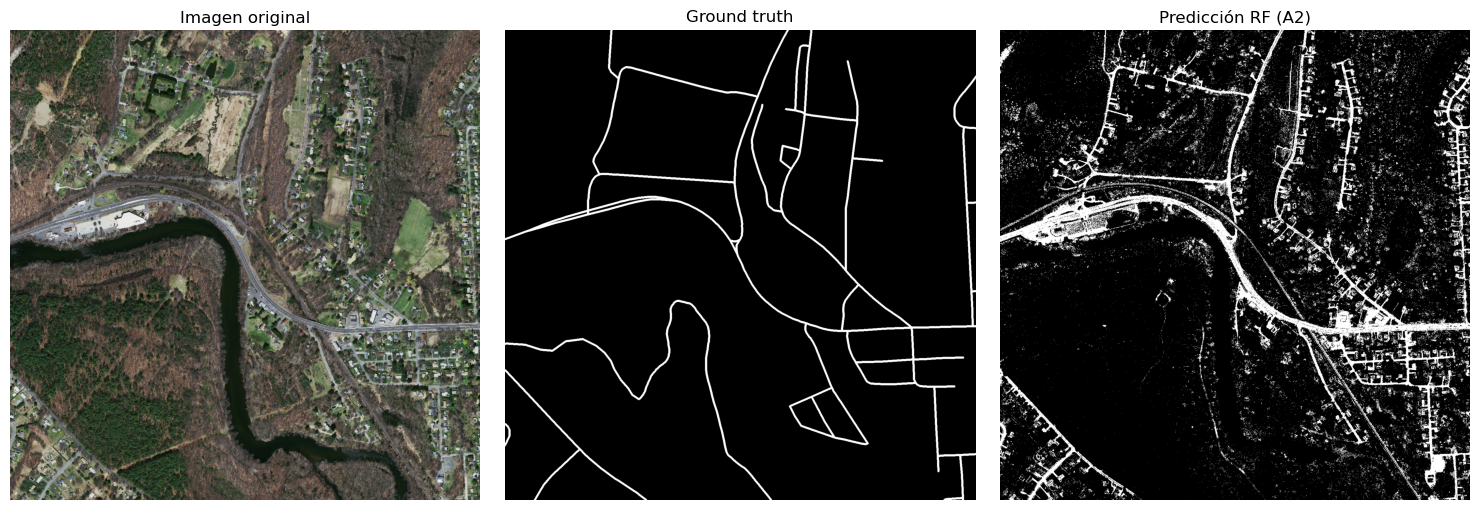

In [144]:
# RANDOM FOREST
# Definimos el modelo.
rf_A2 = RandomForestClassifier(n_estimators=250, max_depth=22, min_samples_leaf=6, min_samples_split=6, max_features=0.25, criterion="entropy",
                               random_state=seed, n_jobs=-1, verbose=1)
# Lo entrenamos 
rf_A2, y_val_pred_rf_A2, y_test_pred_rf_A2, metrics_val_rf_A2, metrics_test_rf_A2 = train_and_evaluate_model(rf_A2, 
                                                                                                             X_train_A2, y_train_A2, 
                                                                                                             X_val_A2, y_val_A2, 
                                                                                                             X_test_A2, y_test_A2, 
                                                                                                             model_name="RandomForest (A2)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA2, "Random Forest (A2)", rf_A2, y_val_pred_rf_A2, y_test_pred_rf_A2, metrics_val_rf_A2, metrics_test_rf_A2)
show_example_prediction(X_val, y_val, y_val_pred_rf_A2, title="Predicción RF (A2)")


=== LogisticRegression (A2): ENTRENAMIENTO ===
Entrenando con 2529114 píxeles...
Modelo entrenado

=== VALIDACIÓN ===

Validación:
  Accuracy:  0.8252
  Precision: 0.2268
  Recall:    0.7460
  Jaccard:   0.2105
  Dice:      0.3478

=== TEST ===

Test:
  Accuracy:  0.8292
  Precision: 0.1147
  Recall:    0.8029
  Jaccard:   0.1115
  Dice:      0.2007


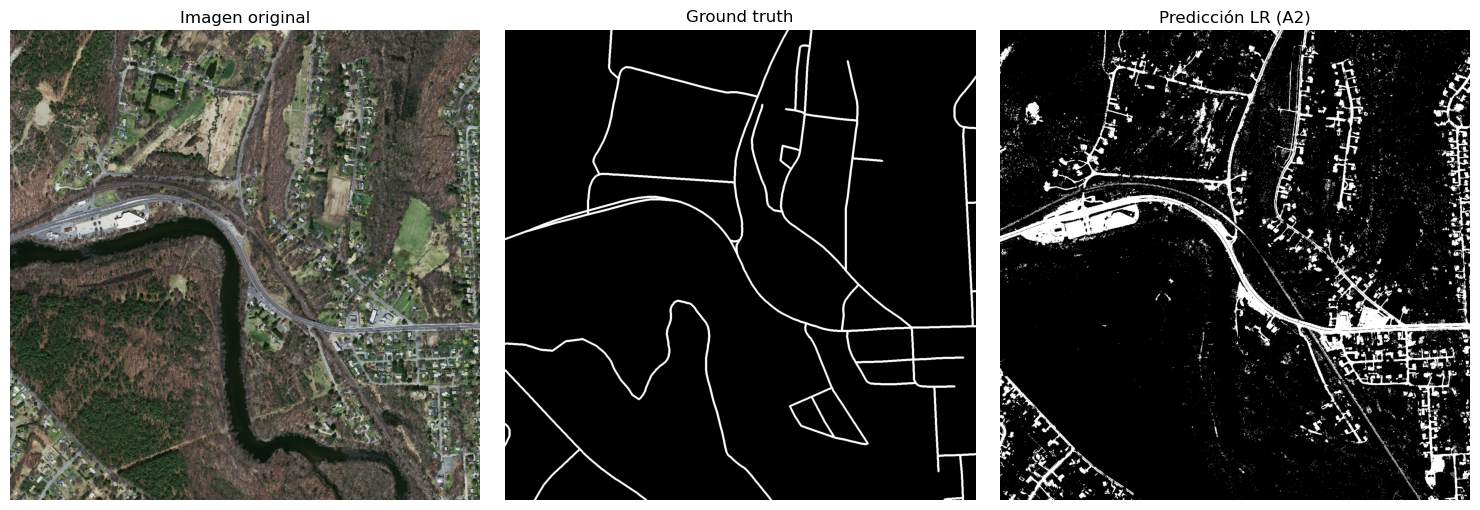

In [146]:
# LOGISTIC REGRESSION
lr_A2 = LogisticRegression(C=30, max_iter=500, random_state=seed)

# Lo entrenamos 
lr_A2, y_val_pred_lr_A2, y_test_pred_lr_A2, metrics_val_lr_A2, metrics_test_lr_A2 = train_and_evaluate_model(lr_A2, 
                                                                                                             X_train_A2, y_train_A2, 
                                                                                                             X_val_A2, y_val_A2, 
                                                                                                             X_test_A2, y_test_A2, 
                                                                                                             model_name="LogisticRegression (A2)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA2, "Logistic Regression (A2)", lr_A2, y_val_pred_lr_A2, y_test_pred_lr_A2, metrics_val_lr_A2, metrics_test_lr_A2)
show_example_prediction(X_val, y_val, y_val_pred_lr_A2, title="Predicción LR (A2)")


=== KNN (A2): ENTRENAMIENTO ===
Entrenando con 2529114 píxeles...
Modelo entrenado

=== VALIDACIÓN ===

Validación:
  Accuracy:  0.8337
  Precision: 0.2391
  Recall:    0.7611
  Jaccard:   0.2224
  Dice:      0.3639

=== TEST ===

Test:
  Accuracy:  0.8394
  Precision: 0.1236
  Recall:    0.8239
  Jaccard:   0.1205
  Dice:      0.2150


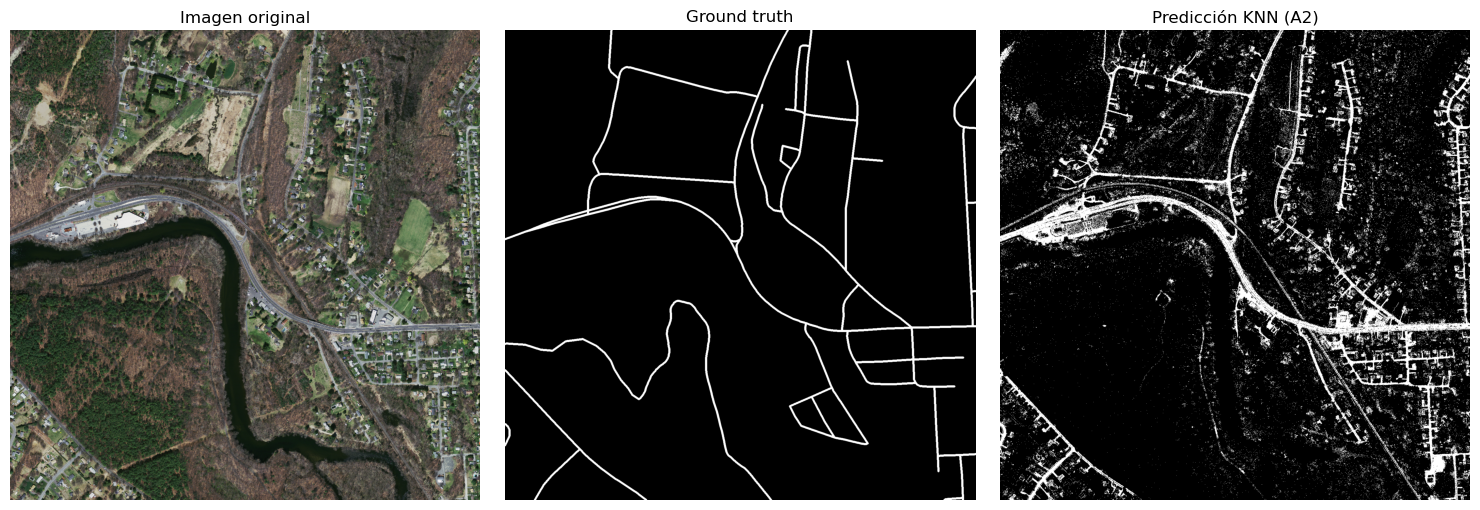

In [147]:
# K NEAREST NEIGHBOURS
knn_A2 = KNeighborsClassifier(n_neighbors=10)

# Lo entrenamos 
knn_A2, y_val_pred_knn_A2, y_test_pred_knn_A2, metrics_val_knn_A2, metrics_test_knn_A2 = train_and_evaluate_model(knn_A2, 
                                                                                                                  X_train_A2, y_train_A2, 
                                                                                                                  X_val_A2, y_val_A2, 
                                                                                                                  X_test_A2, y_test_A2,  
                                                                                                                  model_name="KNN (A2)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA2, "KNN (A2)", knn_A2, y_val_pred_knn_A2, y_test_pred_knn_A2, metrics_val_knn_A2, metrics_test_knn_A2)
show_example_prediction(X_val, y_val, y_val_pred_knn_A2, title="Predicción KNN (A2)")


===  Decision Tree (A2): ENTRENAMIENTO ===
Entrenando con 2529114 píxeles...
Modelo entrenado

=== VALIDACIÓN ===

Validación:
  Accuracy:  0.8274
  Precision: 0.2346
  Recall:    0.7789
  Jaccard:   0.2199
  Dice:      0.3606

=== TEST ===

Test:
  Accuracy:  0.8345
  Precision: 0.1220
  Recall:    0.8392
  Jaccard:   0.1192
  Dice:      0.2131


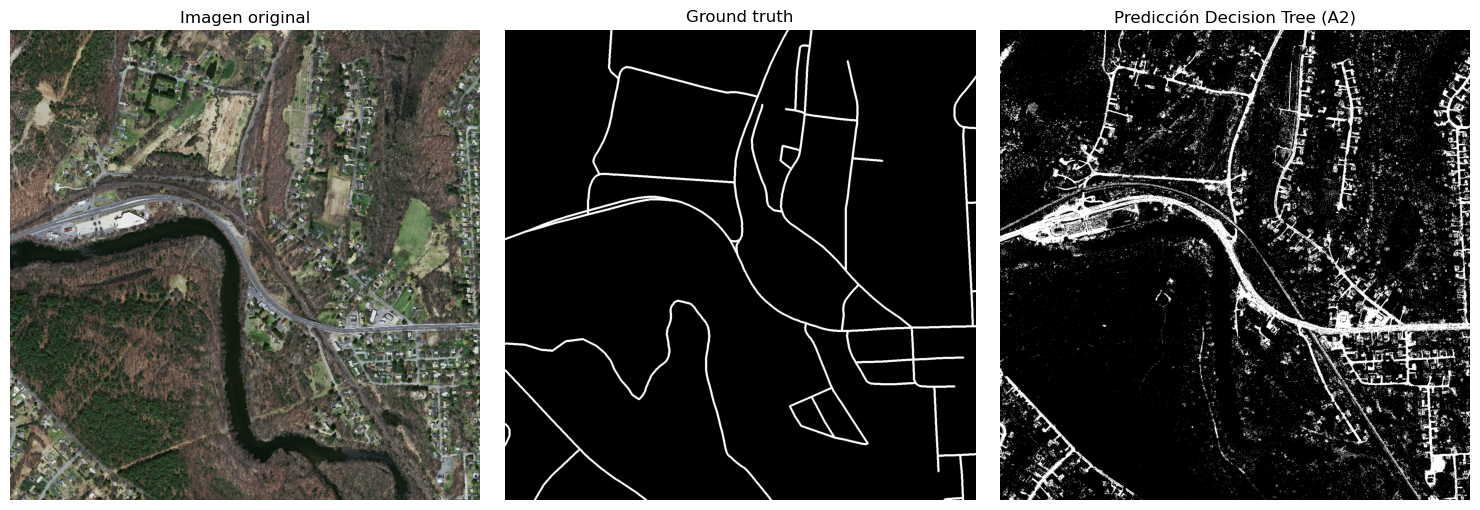

In [154]:
# DECISION TREE 
dt_A2 = DecisionTreeClassifier(max_depth= 150, min_samples_split=80, min_samples_leaf=40, random_state = seed)

# Lo entrenamos 
dt_A2 , y_val_pred_dt_A2 , y_test_pred_dt_A2 , metrics_val_dt_A2 , metrics_test_dt_A2  = train_and_evaluate_model(dt_A2, 
                                                                                                                  X_train_A2, y_train_A2, 
                                                                                                                  X_val_A2, y_val_A2, 
                                                                                                                  X_test_A2, y_test_A2, 
                                                                                                                  model_name=" Decision Tree (A2)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA2, "Decision Tree (A2)", dt_A2 , y_val_pred_dt_A2 , y_test_pred_dt_A2 , metrics_val_dt_A2 , metrics_test_dt_A2)
show_example_prediction(X_val, y_val, y_val_pred_dt_A2, title="Predicción Decision Tree (A2)")


=== SVM (A2): ENTRENAMIENTO ===
Entrenando con 2529114 píxeles...
Modelo entrenado

=== VALIDACIÓN ===

Validación:
  Accuracy:  0.8290
  Precision: 0.2295
  Recall:    0.7362
  Jaccard:   0.2121
  Dice:      0.3499

=== TEST ===

Test:
  Accuracy:  0.8308
  Precision: 0.1148
  Recall:    0.7954
  Jaccard:   0.1115
  Dice:      0.2007


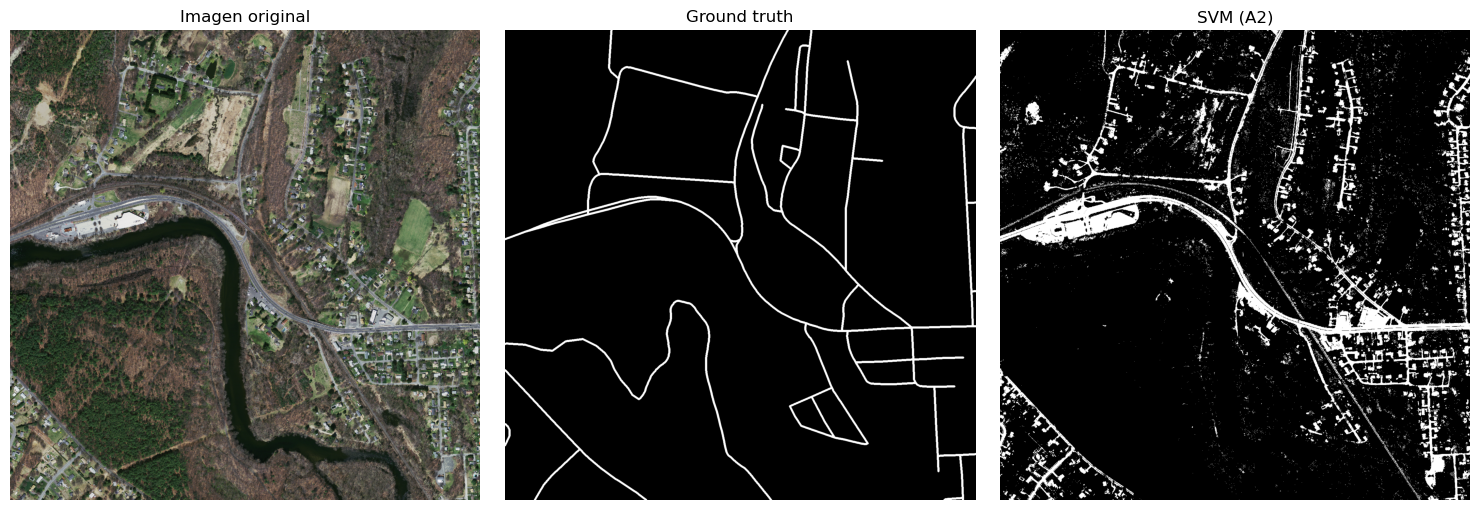

In [149]:
# SVM
svm_A2 = LinearSVC(C=1, max_iter=2000, random_state=seed)

# Lo entrenamos 
svm_A2, y_val_pred_svm_A2, y_test_pred_svm_A2, metrics_val_svm_A2, metrics_test_svm_A2 = train_and_evaluate_model(svm_A2, 
                                                                                                                  X_train_A2, y_train_A2, 
                                                                                                                  X_val_A2, y_val_A2, 
                                                                                                                  X_test_A2, y_test_A2,   
                                                                                                                  model_name="SVM (A2)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA2, "SVM (A2)", svm_A2, y_val_pred_svm_A2, y_test_pred_svm_A2, metrics_val_svm_A2, metrics_test_svm_A2)
show_example_prediction(X_val, y_val, y_val_pred_svm_A2, title="SVM (A2)")

In [151]:
del resultadosA2[1]

In [152]:
df_A2 = tabla_comparativa(resultadosA2, "Escenario A2: Imágenes balanceadas")

Escenario A2: Imágenes balanceadas


,Modelo,Test_Acc,Test_Prec,Test_Rec,Test_Jaccard,Test_Dice
2,KNN (A2),0.839352,0.123635,0.823869,0.120451,0.215005
3,Decision Tree (A2),0.834483,0.122035,0.839197,0.119247,0.213084
0,Random Forest (A2),0.833563,0.121538,0.840221,0.118793,0.212359
1,Logistic Regression (A2),0.829215,0.114673,0.802864,0.111533,0.200683
4,SVM (A2),0.830803,0.114824,0.795366,0.111529,0.200677


### Aproximación 3: Balanceado + Extracción de Características 

In [153]:
X_train_A3, y_train_A3 = prepare_pixel_dataset(X_train, y_train, feature_type="feat", balance_train=True)
print_dataset_info(X_train, y_train, X_train_A3, y_train_A3, "Train")

X_val_A3, y_val_A3 = prepare_pixel_dataset(X_val, y_val, feature_type="feat", balance_train=False)
print_dataset_info(X_val, y_val, X_val_A3, y_val_A3, "Val")

X_test_A3, y_test_A3 = prepare_pixel_dataset(X_test, y_test, feature_type="feat", balance_train=False)
print_dataset_info(X_test, y_test, X_test_A3, y_test_A3, "Test")

resultadosA3 = [] # lista en la que almacenaremos los resultados de todos los modelos


=== Train ===
Rango sin normalizar:0.00-255.00
Rango normalizado: 0.00-1.00
Tamaño aplanado: (2529114, 19) ; (2529114,)

=== Val ===
Rango sin normalizar:0.00-255.00
Rango normalizado: 0.00-1.00
Tamaño aplanado: (4500000, 19) ; (4500000,)

=== Test ===
Rango sin normalizar:0.00-255.00
Rango normalizado: 0.00-1.00
Tamaño aplanado: (4500000, 19) ; (4500000,)


In [ ]:
# K NEAREST NEIGHBOURS
knn_A3 = KNeighborsClassifier(n_neighbors=10)

# Lo entrenamos 
knn_A3, y_val_pred_knn_A3, y_test_pred_knn_A3, metrics_val_knn_A3, metrics_test_knn_A3 = train_and_evaluate_model(knn_A3, 
                                                                                                                  X_train_A3, y_train_A3, 
                                                                                                                  X_val_A3, y_val_A3, 
                                                                                                                  X_test_A3, y_test_A3,  
                                                                                                                  model_name="KNN (A3)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA3, "KNN (A3)", y_val_pred_knn_A3, y_test_pred_knn_A3, metrics_val_knn_A3, metrics_test_knn_A3)
show_example_prediction(X_val, y_val, y_val_pred_knn_A3, title="Predicción KNN (A3)")


=== KNN (A3): ENTRENAMIENTO ===
Entrenando con 2529114 píxeles...
Modelo entrenado

=== VALIDACIÓN ===


In [ ]:
# DECISION TREE
dt_A3 = DecisionTreeClassifier(max_depth= 150, min_samples_split=80, min_samples_leaf=40, random_state = seed)

# Lo entrenamos 
dt_A3 , y_val_pred_dt_A3 , y_test_pred_dt_A3, metrics_val_dt_A3 , metrics_test_dt_A3  = train_and_evaluate_model(dt_A3, 
                                                                                                                  X_train_A3, y_train_A3, 
                                                                                                                  X_val_A3, y_val_A3, 
                                                                                                                  X_test_A3, y_test_A3, 
                                                                                                                  model_name=" Decision Tree (A3)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA3, "Decision Tree (A3)", dt_A3 , y_val_pred_dt_A3 , y_test_pred_dt_A3, metrics_val_dt_A3 , metrics_test_dt_A3)
show_example_prediction(X_val, y_val, y_val_pred_dt_A3, title="Predicción Decision Tree (A3)")

In [ ]:
# RANDOM FOREST
# Definimos el modelo.
rf_A3 = RandomForestClassifier(n_estimators=250, max_depth=22, min_samples_leaf=6, min_samples_split=6, max_features=0.25, criterion="entropy",
                               random_state=seed, n_jobs=-1, verbose=1)

# Lo entrenamos 
rf_A3, y_val_pred_rf_A3, y_test_pred_rf_A3, metrics_val_rf_A3, metrics_test_rf_A3 = train_and_evaluate_model(rf_A3, 
                                                                                                             X_train_A3, y_train_A3, 
                                                                                                             X_val_A3, y_val_A3, 
                                                                                                             X_test_A3, y_test_A3, 
                                                                                                             model_name="RandomForest (A3)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA3, "Random Forest (A3)", rf_A3, y_val_pred_rf_A3, y_test_pred_rf_A3, metrics_val_rf_A3, metrics_test_rf_A3)
show_example_prediction(X_val, y_val, y_val_pred_rf_A3, title="Predicción RF (A3)")

In [ ]:
svm_A3 = LinearSVC(C=1, max_iter=2000, random_state=seed)

# Lo entrenamos 
svm_A3, y_val_pred_svm_A3, y_test_pred_svm_A3, metrics_val_svm_A3, metrics_test_svm_A3 = train_and_evaluate_model(svm_A3, 
                                                                                                                  X_train_A3, y_train_A3, 
                                                                                                                  X_val_A3, y_val_A3, 
                                                                                                                  X_test_A3, y_test_A3,   
                                                                                                                  model_name="SVM (A3)")
# Guardamos los resultados y visualizamos 
guardar_resultado(resultadosA3, "SVM (A3)", svm_A2, y_val_pred_svm_A2, y_test_pred_svm_A2, metrics_val_svm_A2, metrics_test_svm_A2)
show_example_prediction(X_val, y_val, y_val_pred_svm_A3, title="SVM (A3)")

In [ ]:
df_A3 = tabla_comparativa(resultadosA3, "Escenario A3: Imágenes balanceadas + extracción de características")

### Tabla comparativa global

In [ ]:
# best_A1 = mejor_modelo(resultados_A1)
best_A2 = mejor_modelo(resultados_A2)
best_A3 = mejor_modelo(resultados_A3)

#resultados_global = [best_A1, best_A2, best_A3]
resultados_global = [best_A2, best_A3]
df_global = tabla_comparativa(resultados_global, "Comparación de escenarios (mejor de cada uno)")

### Postprocesado